# Import Required Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

This cell imports the necessary libraries:

* torch – core deep learning framework.

* torch.nn – contains neural network layers and loss functions.

* torchvision – used to load datasets like CIFAR-10.

* matplotlib – used for visualization of reconstructed images.

* numpy – used for numerical operations.

# Device Configuration

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


This cell checks whether a GPU (CUDA) is available.

If GPU exists → training becomes faster.

Otherwise → training runs on CPU.

# Data Preprocessing and Transformations

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

This cell defines preprocessing steps:

1. ToTensor()

* Converts images to PyTorch tensors.

2. Normalize

* Scales pixel values to a range roughly between -1 and 1.

* Helps neural networks train more efficiently.

# Load CIFAR-10 Dataset

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:06<00:00, 27.1MB/s]


This cell downloads and loads the CIFAR-10 dataset.

Dataset characteristics:

* 60,000 images

* 32 × 32 RGB images

* 10 classes (airplane, car, bird, cat, etc.)

Training set → 50,000 images
Test set → 10,000 images

# Create DataLoaders

In [ ]:
batch_size = 128

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

DataLoader:

* Splits dataset into mini-batches

* Batch size = 128

* Shuffle=True improves training by randomizing input order.

### Define Sparse Autoencoder Model

In [ ]:
class SparseAutoencoder(nn.Module):

    def __init__(self, input_dim=3072, hidden_dim=512, sparsity_lambda=1e-6, sparsity_target=0.05):
        super(SparseAutoencoder, self).__init__()

        self.sparsity_lambda = sparsity_lambda
        self.sparsity_target = sparsity_target

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

This defines the Sparse Autoencoder architecture.

Structure:

Input Layer

→ Encoder (3072 → 512)

→ Latent representation

→ Decoder (512 → 3072)

→ Reconstructed image

Key idea:

* Encoder compresses data

* Decoder reconstructs original input

# Sparsity Penalty Function

In [ ]:
def sparsity_penalty(encoded, sparsity_target=0.05):

    epsilon = 1e-8

    rho_hat = torch.mean(encoded, dim=0)
    rho_hat = torch.clamp(rho_hat, epsilon, 1 - epsilon)

    rho = torch.tensor(sparsity_target).to(encoded.device)

    kl = rho * torch.log(rho / rho_hat) + \
         (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)

## Demonstrating Different Sparsity Parameter

Let's try a higher sparsity penalty (`sparsity_lambda = 1e-4`) to observe its effect on the reconstruction quality.

In [ ]:
model_high_sparsity = SparseAutoencoder().to(device)
criterion_high_sparsity = nn.MSELoss()
optimizer_high_sparsity = optim.Adam(model_high_sparsity.parameters(), lr=0.001)

### Training Loop with Higher Sparsity Penalty

In [ ]:
num_epochs_high_sparsity = 10
sparsity_lambda_high_sparsity = 1e-4 # Increased sparsity lambda

print(f"Training with sparsity_lambda = {sparsity_lambda_high_sparsity}")

for epoch in range(num_epochs_high_sparsity):

    total_loss_high_sparsity = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, decoded = model_high_sparsity(images)

        recon_loss = criterion_high_sparsity(decoded, images)

        # Using absolute mean for sparsity loss as in the original training loop
        sparsity_loss = torch.mean(torch.abs(encoded))

        loss = recon_loss + sparsity_lambda_high_sparsity * sparsity_loss

        optimizer_high_sparsity.zero_grad()
        loss.backward()
        optimizer_high_sparsity.step()

        total_loss_high_sparsity += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs_high_sparsity}], Loss: {total_loss_high_sparsity/len(train_loader):.4f}")

Training with sparsity_lambda = 0.0001
Epoch [1/10], Loss: 0.2050
Epoch [2/10], Loss: 0.1763
Epoch [3/10], Loss: 0.1676
Epoch [4/10], Loss: 0.1630
Epoch [5/10], Loss: 0.1599
Epoch [6/10], Loss: 0.1578
Epoch [7/10], Loss: 0.1562
Epoch [8/10], Loss: 0.1551
Epoch [9/10], Loss: 0.1541
Epoch [10/10], Loss: 0.1533


### Evaluate Model with Higher Sparsity on Test Data

In [ ]:
model_high_sparsity.eval()

test_loss_high_sparsity = 0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1).to(device)

        _, decoded = model_high_sparsity(images)

        loss = criterion_high_sparsity(decoded, images)

        test_loss_high_sparsity += loss.item()

print("Test Reconstruction Loss (Higher Sparsity):", test_loss_high_sparsity / len(test_loader))

Test Reconstruction Loss (Higher Sparsity): 0.1509787900538384


### Visualize Original vs Reconstructed Images (Higher Sparsity)

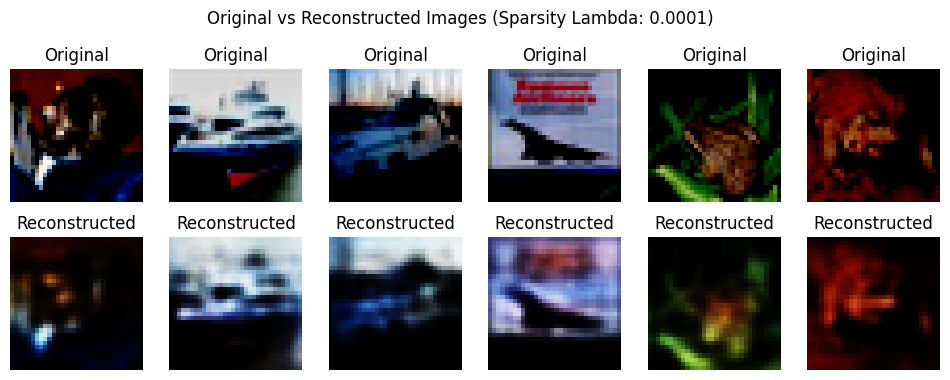

In [ ]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1).to(device)

_, outputs = model_high_sparsity(images_flat)

images = images.numpy()
outputs = outputs.view(outputs.size(0),3,32,32).cpu().detach().numpy()

# Denormalize images for correct visualization
mean = np.array([0.5, 0.5, 0.5]).reshape((1, 3, 1, 1))
std = np.array([0.5, 0.5, 0.5]).reshape((1, 3, 1, 1))
images = images * std + mean
outputs = outputs * std + mean

fig, axes = plt.subplots(2,6, figsize=(12,4))

for i in range(6):

    axes[0,i].imshow(np.transpose(images[i],(1,2,0)))
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    axes[1,i].imshow(np.transpose(outputs[i],(1,2,0)))
    axes[1,i].set_title("Reconstructed")
    axes[1,i].axis("off")

plt.suptitle(f"Original vs Reconstructed Images (Sparsity Lambda: {sparsity_lambda_high_sparsity})", y=1.02)
plt.show()

This function implements the KL divergence sparsity constraint.

Goal:

* Keep most neurons inactive

* Only a few neurons fire for each input.

This improves feature representation learning.

# Initialize Model, Loss and Optimizer

In [ ]:
model = SparseAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

Components used for training:

* Model – Sparse Autoencoder

* Loss Function – Mean Squared Error (reconstruction loss)

* Optimizer – Adam optimizer

* Learning rate = 0.001

# Training Loop

In [ ]:
num_epochs = 10
sparsity_lambda =poo

for epoch in range(num_epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, decoded = model(images)

        recon_loss = criterion(decoded, images)

        sparsity_loss = torch.mean(torch.abs(encoded))

        loss = recon_loss + sparsity_lambda * sparsity_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.2048
Epoch [2/10], Loss: 0.1761
Epoch [3/10], Loss: 0.1673
Epoch [4/10], Loss: 0.1627
Epoch [5/10], Loss: 0.1598
Epoch [6/10], Loss: 0.1577
Epoch [7/10], Loss: 0.1561
Epoch [8/10], Loss: 0.1550
Epoch [9/10], Loss: 0.1540
Epoch [10/10], Loss: 0.1532


This cell trains the autoencoder.

Training steps:

1. Flatten images

* 32 × 32 × 3 = 3072

2. Forward pass

3. Compute losses:

* Reconstruction Loss

* Sparsity Loss

4. Backpropagation

5. Update weights.

# Evaluate Model on Test Data

In [ ]:
model.eval()

test_loss = 0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1).to(device)

        _, decoded = model(images)

        loss = criterion(decoded, images)

        test_loss += loss.item()

print("Test Reconstruction Loss:", test_loss / len(test_loader))

Test Reconstruction Loss: 0.1509981528867649


This cell evaluates the trained model.

* No gradient computation

* Only forward pass

* Calculates average reconstruction loss

Lower loss → better reconstruction.

# Visualize Original vs Reconstructed Images

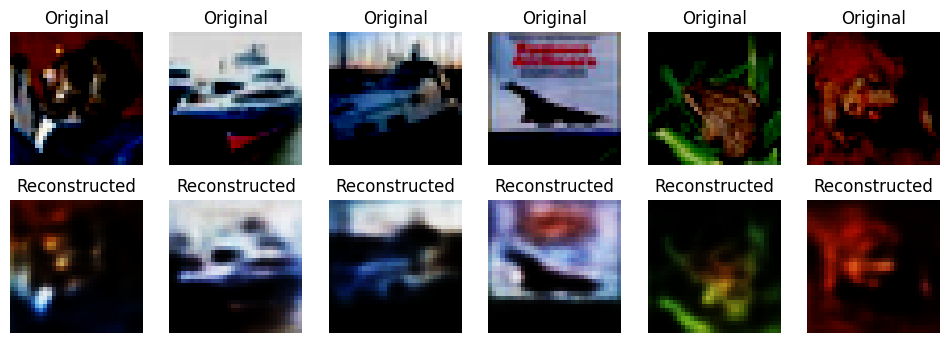

In [ ]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1).to(device)

_, outputs = model(images_flat)

images = images.numpy()
outputs = outputs.view(outputs.size(0),3,32,32).cpu().detach().numpy()

fig, axes = plt.subplots(2,6, figsize=(12,4))

for i in range(6):

    axes[0,i].imshow(np.transpose(images[i],(1,2,0)))
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    axes[1,i].imshow(np.transpose(outputs[i],(1,2,0)))
    axes[1,i].set_title("Reconstructed")
    axes[1,i].axis("off")

plt.show()

This cell visualizes results.

Top row → Original images
Bottom row → Reconstructed images

This helps observe how well the autoencoder learned image features.